In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
version = '2.1'

# Load the file
df = pd.read_csv(f"{version}.csv")

# View the first 5 rows
df.head()

,Width,Depth
0,0,180.0
1,20,140.0
2,80,20.0
3,110,-14.5
4,310,-13.0


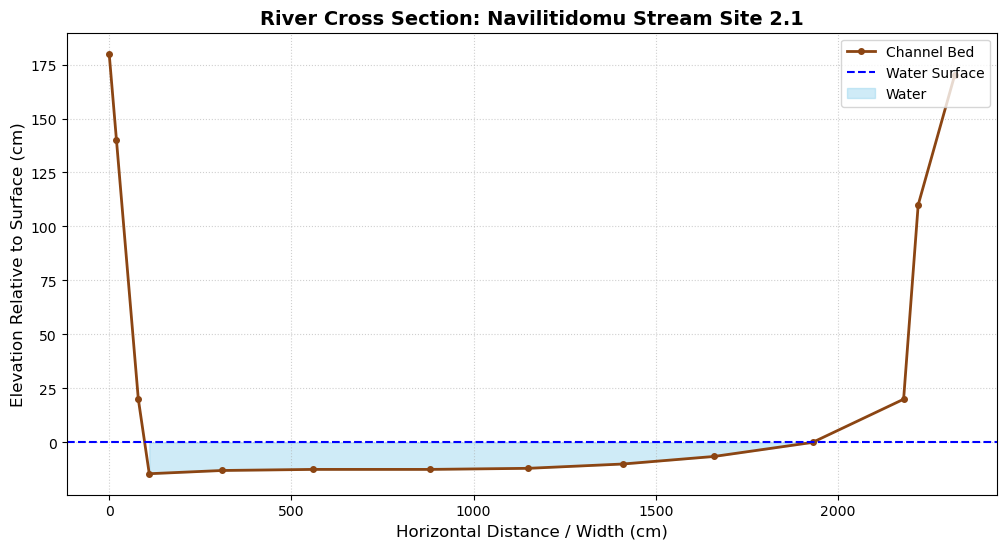

In [3]:
# 1. Load your site data
df = pd.read_csv(f"{version}.csv")

# 2. Create the plot
plt.figure(figsize=(12, 6))

# Plot the channel bed
plt.plot(df['Width'], df['Depth'], color='#8B4513', linewidth=2, marker='o', markersize=4, label='Channel Bed')

# Draw the water surface line at 0
plt.axhline(0, color='blue', linestyle='--', linewidth=1.5, label='Water Surface')

# Fill the water area (everything between the bed and 0 where depth is negative)
plt.fill_between(df['Width'], df['Depth'], 0, where=(df['Depth'] <= 0), 
                 color='skyblue', alpha=0.4, label='Water')

# 3. Aesthetics
plt.title(f"River Cross Section: Navilitidomu Stream Site {version}", fontsize=14, fontweight='bold')
plt.xlabel('Horizontal Distance / Width (cm)', fontsize=12)
plt.ylabel('Elevation Relative to Surface (cm)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

# Optional: Set equal aspect ratio if you want to see the "true" shape
# plt.axis('equal') 

plt.show()

In [4]:
# 1. Load your clean site CSV
df = pd.read_csv(f'{version}.csv')

# 2. Identify the "Wet" part of the channel
# We only care about rows where Depth <= 0 (submerged)
water_df = df[df['Depth'] <= 0].copy()

# Convert negative depths to positive heights (h) for area calculation
water_df['h'] = water_df['Depth'] * -1

In [5]:
# 3. CALCULATE AREA (A) using the Trapezoidal Rule
# This calculates the integral of height over width
area = np.trapz(water_df['h'], x=water_df['Width'])
print(f"Cross-sectional Area (A): {area:.2f} cm²")

Cross-sectional Area (A): 19045.00 cm²


In [6]:
# 4. CALCULATE WETTED PERIMETER (P)
# P is the length of the line along the river bed
# Distance = sqrt( (x2-x1)^2 + (y2-y1)^2 )
dx = water_df['Width'].diff()
dy = water_df['Depth'].diff()
distances = np.sqrt(dx**2 + dy**2)
wetted_perimeter = distances.sum()
print(f"Wetted Perimeter (P): {wetted_perimeter:.2f} cm")


Wetted Perimeter (P): 1820.12 cm


In [7]:
# 5. CALCULATE HYDRAULIC RADIUS (Rh)
# Rh = Area / Wetted Perimeter
hydraulic_radius = area / wetted_perimeter
print(f"Hydraulic Radius (Rh): {hydraulic_radius:.2f} cm")

Hydraulic Radius (Rh): 10.46 cm


In [8]:
# Lookup values for Cowan components
n_lookup = {
    'substrate': {'sand': 0.020, 'silt': 0.020, 'silty_clay': 0.025, 'gravel': 0.028, 'cobbles' : 0.035},
    'texture': {'very_smooth': 0.000, 'smooth': 0.005, 'moderate': 0.010, 'rough':0.020},
    'variations': {'very_gradual': 0.000, 'gradual': 0.005, 'abrupt': 0.010},
    'obstructions': {'negligible': 0.000, 'minor': 0.005, 'moderate': 0.010, 'substantial':0.40},
    'vegetation': {'low': 0.000, 'medium': 0.005, 'high': 0.010},
    'meandering': {'negligible': 1, 'minor': 5, 'moderate': 25, 'high': 50}
}

In [9]:
# 2. MANUALLY define the characteristics for "Site 1.1" 
# (Replace these with your actual field observations)
site_properties = {
    'substrate': 'silty_clay',
    'texture': 'smooth',
    'variations': 'very_gradual',
    'obstructions': 'minor',
    'vegetation': 'medium',
    'meandering': 'negligible'
}

# 3. Perform the lookup using your manual choices
base_n    = n_lookup['substrate'][site_properties['substrate']]
texture_n = n_lookup['texture'][site_properties['texture']]
var_n     = n_lookup['variations'][site_properties['variations']]
obstruction_n     = n_lookup['obstructions'][site_properties['obstructions']]
vegetation_n     = n_lookup['vegetation'][site_properties['vegetation']]
meandering_m  = n_lookup['meandering'][site_properties['meandering']]

# 4. Calculate final Manning's n
# Formula: n = (n0 + n1 + n2) * m
final_m = (base_n + texture_n + var_n + obstruction_n + vegetation_n)*meandering_m 

print(f"Calculated Manning's n for Site 1.1: {final_m:.3f}")

Calculated Manning's n for Site 1.1: 0.040


In [10]:
pulses = 353.625

In [11]:
p_t = pulses/60

In [12]:
velocity = 0.2520*p_t + 0.006

In [13]:
area_m2 = area/10000

In [14]:
area_m2

1.9045

In [15]:
velocity

1.491225

In [16]:
slope = 0.2

In [17]:
discharge = area_m2 * velocity

In [18]:
print(discharge, 'm3/s')

2.8400380125 m3/s


In [19]:
import pandas as pd

# 1. Create a dictionary with your calculated variables
summary_data = {
    'Site': f"SITE {version}",
    'Area (m2)': area_m2,
    'Wetted Perimeter (cm)': wetted_perimeter,
    'Hydraulic Radius (cm)': hydraulic_radius,
    'Mannings m': final_m,        # From your lookup/field notes
    'Slope': slope,
    'Velocity_m/s': velocity,
    'Discharge_m3/s': discharge
    # 'Discharge (m3/s)': discharge
}

# 2. Turn it into a DataFrame (single row)
results_df = pd.DataFrame([summary_data])

# 3. View the summary
results_df

,Site,Area (m2),Wetted Perimeter (cm),Hydraulic Radius (cm),Mannings m,Slope,Velocity_m/s,Discharge_m3/s
0,SITE 2.1,1.9045,1820.117008,10.463613,0.04,0.2,1.491225,2.840038


In [20]:
results_df.to_csv(f"{version}_results_df.csv")